In [1]:
from google.colab import drive
drive.mount("/content/drive")

# CHANGE this to your repo folder
%cd /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
!ls

Mounted at /content/drive
/content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
build_and_test.sh   experiments  pyproject.toml  src	     test.sh
CODE_OF_CONDUCT.md  LICENSE	 README.md	 SUPPORT.md
data		    pipelines	 SECURITY.md	 tests


In [ ]:
!pip install -e .

In [ ]:
import slicegpt
from slicegpt import rotate, model_utils
print("slicegpt imported:", slicegpt.__file__)
print("rotate imported:", rotate.__file__)
print("model_utils imported:", model_utils.__file__)

slicegpt imported: /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src/slicegpt/__init__.py
rotate imported: /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src/slicegpt/rotate.py
model_utils imported: /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src/slicegpt/model_utils.py


In [3]:
import os, textwrap

# Where to save logs and models in your Drive
BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
LOG_DIR = os.path.join(BASE_RESULTS_DIR, "logs_qwen2_0.5B")
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_qwen2_0.5B")
BASE_EVAL_DIR = os.path.join(BASE_RESULTS_DIR, "eval")

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

sparsities = [0.0, 0.10, 0.25, 0.4, 0.6]
datasets = ["wikitext2", "squad", "hotpotqa"]

print("Logs in:", LOG_DIR)
print("Models in:", MODEL_DIR)

Logs in: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/logs_qwen2_0.5B
Models in: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_qwen2_0.5B


In [ ]:
# Cell 1: Slicing with correct dtype
import os
import subprocess
from datetime import datetime

MODEL_ID = "Qwen/Qwen2-0.5B"

def run_slicegpt(dataset, sparsity):
    log_name = f"{MODEL_ID.replace('/','-')}_{dataset}_s{sparsity:.2f}.txt".replace(".", "p")
    log_path = os.path.join(LOG_DIR, log_name)

    if os.path.exists(log_path):
        print(f"[SKIP] Log already exists for {dataset}, sparsity={sparsity}: {log_path}")
        return

    save_dir = os.path.join(MODEL_DIR, f"{MODEL_ID.replace('/','-')}_{dataset}_s{sparsity:.2f}".replace(".", "p"))
    os.makedirs(save_dir, exist_ok=True)

    cmd = [
        "python",
        "/content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/experiments/run_slicegpt.py",
        "--model", MODEL_ID,
        "--cal-dataset", dataset,
        "--save-dir", save_dir,
        "--sparsity", str(sparsity),
        "--device", "cuda:0",
        "--no-wandb",
        "--cal-batch-size", "8"
        # Removed --dtype flag - will use model's default (fp16 for Gemma)
    ]

    print("\n=====================================================")
    print("Running:", " ".join(cmd))
    print("Log file:", log_path)
    print("Start:", datetime.now())
    print("=====================================================\n")

    with open(log_path, "w") as f:
        process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            print(line, end="")
            f.write(line)

    ret = process.wait()
    print("\nFinished with return code:", ret)
    print("End:", datetime.now())

for dataset in datasets:
    for s in sparsities:
        run_slicegpt(dataset, s)

In [ ]:
# Simplified generation test for Qwen3-0.6B (SQuAD, s0.10) - forward + FP32 + 5 generations
import torch
from slicegpt import hf_utils

MODEL_NAME = "Qwen/Qwen2-0.5B"
SLICED_DIR  = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_qwen2/Qwen-Qwen2-0p5B_squad_s0p10"
SPARSITY    = 0.10

print(f"Running generation tests for {MODEL_NAME} (SQuAD, sparsity={SPARSITY})...")

model_adapter, tokenizer = hf_utils.load_sliced_model(
    MODEL_NAME,
    SLICED_DIR,
    sparsity=SPARSITY
)

# Qwen (causal LM) often doesn't define pad_token -> set it to eos for generate()
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

# Use one prompt tensor for forward tests
prompt = "Hello"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

# ----------------------------
# FP16 forward pass
# ----------------------------
model_fp16 = model_adapter.model.to(device="cuda", dtype=torch.float16).eval()

print("\n" + "="*60)
print("FORWARD PASS TEST (FP16)")
print("="*60)

with torch.no_grad():
    try:
        out = model_fp16(**inputs)
        logits_finite = torch.isfinite(out.logits).all().item()

        if logits_finite:
            print("✓ FP16 forward pass completed successfully - no NaN/Inf detected")
            print(f"  Logits: mean={out.logits.mean().item():.4f}, std={out.logits.std().item():.4f}")
        else:
            print("✗ FP16 logits contain NaN/Inf")
    except Exception as e:
        print(f"✗ FP16 forward pass failed with error: {e}")
        import traceback
        traceback.print_exc()

# ----------------------------
# FP32 forward pass
# ----------------------------
print("\n" + "="*60)
print("FORWARD PASS TEST (FP32)")
print("="*60)

model_fp32 = model_adapter.model.to(device="cuda", dtype=torch.float32).eval()

with torch.no_grad():
    try:
        out_fp32 = model_fp32(**inputs)
        logits_finite_fp32 = torch.isfinite(out_fp32.logits).all().item()

        if logits_finite_fp32:
            print("✓ FP32 forward pass completed successfully - no NaN/Inf detected")
            print(f"  Logits: mean={out_fp32.logits.mean().item():.4f}, std={out_fp32.logits.std().item():.4f}")
        else:
            print("✗ FP32 logits contain NaN/Inf")
    except Exception as e:
        print(f"✗ FP32 forward pass failed with error: {e}")
        import traceback
        traceback.print_exc()

# ----------------------------
# Generation tests
# ----------------------------
print("\n" + "="*60)
print("GENERATION TESTS (5 PROMPTS)")
print("="*60)

test_prompts = [
    "The capital of France is",
    "Machine learning is",
    "In the year 2024,",
    "The theory of relativity",
    "Artificial intelligence will"
]

for idx, test_prompt in enumerate(test_prompts, 1):
    print(f"\n--- Generation Test {idx} ---")
    gen_inputs = tokenizer(test_prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        try:
            gen = model_fp32.generate(
                **gen_inputs,
                max_new_tokens=10,
                do_sample=False,
                num_beams=1,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

            # For causal LM: the decoded text includes the prompt + continuation
            output_text = tokenizer.decode(gen[0], skip_special_tokens=True)
            input_text  = tokenizer.decode(gen_inputs["input_ids"][0], skip_special_tokens=True)

            # Check whether we generated beyond the prompt length (token-based, more reliable)
            generated_new = gen.shape[1] > gen_inputs["input_ids"].shape[1]

            print(f"  Input:  '{input_text}'")
            print(f"  Output: '{output_text}'")
            print(f"  Generated new tokens: {'✓' if generated_new else '✗'}")

        except Exception as e:
            print(f"  ✗ Generation failed: {e}")

print("\n" + "="*60)
print("TEST COMPLETE")
print("="*60)


In [2]:
import logging
import sys

# Get the root logger or a named logger
logger = logging.getLogger()
logger.setLevel(logging.INFO)  # allow INFO and above

for h in list(logger.handlers):
  logger.removeHandler(h)

# Create a handler that writes to stdout
handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.INFO)

# (Optional) set a formatting for readability
formatter = logging.Formatter('%(levelname)s - %(message)s')
handler.setFormatter(formatter)

# Add handler to the logger
logger.addHandler(handler)

# Now test
logger.info("This will be printed to stdout")
logger.debug("This will not print (level is INFO)")

INFO - This will be printed to stdout


In [ ]:
!pip uninstall -y lm-eval lm_eval
!pip install "lm-eval==0.4.2"


In [ ]:
!pip uninstall -y peft
!pip install "peft==0.10.0"


In [ ]:
import os, json, logging
import lm_eval
from lm_eval import utils as lm_eval_utils
from lm_eval.models.huggingface import HFLM
from lm_eval.tasks import TaskManager

from slicegpt import hf_utils
from slicegpt.config import config

logger = logging.getLogger(__name__)

def eval(args):
    logger.info("Running Evaluation")
    logger.info(
        f"Loading sliced {args['model']} from {args['sliced_model_path']} "
        f"with sparsity {args['sparsity']}"
    )

    model_adapter, tokenizer = hf_utils.load_sliced_model(
        args["model"],
        args["sliced_model_path"],
        sparsity=args["sparsity"],
        token=None,
        round_interval=args.get("round_interval", None),
    )

    if hasattr(model_adapter.model, "tie_weights"):
        model_adapter.model.tie_weights = lambda *x, **kw: None

    model_adapter.model.to(config.device)

    hflm = HFLM(
        pretrained=model_adapter.model,
        tokenizer=tokenizer,
        batch_size=args["batch_size"],
    )

    # ---- Task selection (TaskManager is the source of truth) ----
    tm = args.get("task_manager") or TaskManager()
    all_task_names = list(tm.all_tasks) if isinstance(tm.all_tasks, list) else list(tm.all_tasks.keys())

    if args["tasks"] is None:
        task_names = sorted(all_task_names)
    else:
        patterns = (
            [t.strip() for t in args["tasks"].split(",") if t.strip()]
            if isinstance(args["tasks"], str)
            else list(args["tasks"])
        )
        task_names = lm_eval_utils.pattern_match(patterns, all_task_names)

    logger.info(f"Selected Tasks: {task_names}")

    results = lm_eval.simple_evaluate(
        model=hflm,
        tasks=task_names,
        task_manager=tm,
        num_fewshot=args["num_fewshot"],
        batch_size=args["batch_size"],
        limit=args["limit"],
        write_out=False,
        log_samples=False,
    )["results"]

    os.makedirs(args["save_dir"], exist_ok=True)
    sparsity_tag = f"{args['sparsity']:.2f}"
    out_path = os.path.join(args["save_dir"], f"results_s{sparsity_tag}_{'_'.join(task_names)}.json")
    with open(out_path, "w") as f:
        json.dump(results, f, indent=2)

    logger.info(f"Saved results to {out_path}")
    return results


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!mkdir -p data
!wget -O data/hotpot_dev_distractor_v1.json http://curtis.ml.cmu.edu/datasets/hotpot/hotpot_dev_distractor_v1.json
!ls -lh data/hotpot_dev_distractor_v1.json

In [ ]:
from lm_eval import evaluator
from lm_eval.tasks import TaskManager
model = "Qwen/Qwen2-0.5B"
model_name = model.replace("/", "-")
sparsities = [0.0, 0.10, 0.25, 0.40, 0.60]
#sparsities = [0.0]

dir_prefix = "Qwen2-0.5B"

MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_qwen2_0.5B")

results = None
tm = TaskManager()

for dataset in datasets:
  for sparsity in sparsities:
    EVAL_DIR = os.path.join(
    BASE_EVAL_DIR,
    dir_prefix,
    f"{model_name}_{dataset}"
    )
    os.makedirs(EVAL_DIR, exist_ok=True)

    args = {
        "model": model,
        "sliced_model_path": os.path.join(MODEL_DIR, f"{dataset}_s{sparsity:.2f}".replace(".", "p")),
        "sparsity": sparsity,
        "save_dir": EVAL_DIR,
        "tasks": ["squadv2"],
        "num_fewshot": 0,
        "batch_size": 16,
        "round_interval": 8,
        "limit": 1000,
        "task_manager": tm,
    }

    results = eval(args)

In [ ]:
import os, json, torch, re, string
from tqdm import tqdm
from collections import Counter
from slicegpt import hf_utils

def build_context(example):
    paragraphs = []
    for paragraph_title, sentences in example["context"]:
        paragraphs.append(f"[{paragraph_title}] " + " ".join(sentences))
    return "\n".join(paragraphs)

def get_max_input_len(tokenizer, model):
    tmax = getattr(tokenizer, "model_max_length", None)
    if tmax and tmax < 10**6:
        return int(tmax)
    mmax = getattr(model.config, "max_position_embeddings", None)
    if mmax:
        return int(mmax)
    return 2048


In [ ]:
@torch.inference_mode()
def generate_hotpot_predictions_sliced(
    model_name: str,
    sliced_model_path: str,
    sparsity: float,
    hotpot_path: str,
    out_path: str,
    limit: int | None = None,
    max_new_tokens: int = 64,
    round_interval: int | None = None,
):
    model_adapter, tokenizer = hf_utils.load_sliced_model(
        model_name,
        sliced_model_path,
        sparsity=sparsity,
        token=None,
        round_interval=round_interval,
    )
    model = model_adapter.model.cuda().eval()

    # pad token handling
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    model.generation_config.pad_token_id = tokenizer.pad_token_id

    max_inp = get_max_input_len(tokenizer, model)

    with open(hotpot_path, "r", encoding="utf-8") as f:
        examples = json.load(f)

    if limit is None:
        limit = len(examples)

    predictions = {"answer": {}, "sp": {}}

    for ex in tqdm(examples[:limit]):
        qid = ex["_id"]
        question = ex["question"]
        context_text = build_context(ex)

        prompt = (
            "Answer the question using the context. Reply only with a short answer.\n\n"
            f"Context:\n{context_text}\n\n"
            f"Question: {question}\n"
            "Answer:"
        )

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=max_inp,
        ).to(model.device)

        gen = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

        completion = tokenizer.decode(
            gen[0][inputs["input_ids"].shape[-1]:],
            skip_special_tokens=True
        )
        short_answer = completion.splitlines()[0].strip()

        predictions["answer"][qid] = short_answer
        predictions["sp"][qid] = []  # no supporting facts predicted

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(predictions, f)

    return out_path


In [ ]:
def normalize_answer(s):
    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)
    def white_space_fix(text):
        return " ".join(text.split())
    def remove_punc(text):
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)
    def lower(text):
        return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def f1_score(prediction, ground_truth):
    normalized_prediction = normalize_answer(prediction)
    normalized_ground_truth = normalize_answer(ground_truth)

    ZERO_METRIC = (0, 0, 0)

    if normalized_prediction in ["yes", "no", "noanswer"] and normalized_prediction != normalized_ground_truth:
        return ZERO_METRIC
    if normalized_ground_truth in ["yes", "no", "noanswer"] and normalized_prediction != normalized_ground_truth:
        return ZERO_METRIC

    prediction_tokens = normalized_prediction.split()
    ground_truth_tokens = normalized_ground_truth.split()
    common = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return ZERO_METRIC

    precision = 1.0 * num_same / len(prediction_tokens)
    recall = 1.0 * num_same / len(ground_truth_tokens)
    f1 = (2 * precision * recall) / (precision + recall)
    return f1, precision, recall

def exact_match_score(prediction, ground_truth):
    return normalize_answer(prediction) == normalize_answer(ground_truth)

def update_answer(metrics, prediction, gold):
    em = exact_match_score(prediction, gold)
    f1, prec, recall = f1_score(prediction, gold)
    metrics["em"] += float(em)
    metrics["f1"] += f1
    metrics["prec"] += prec
    metrics["recall"] += recall
    return em, prec, recall

def update_sp(metrics, prediction, gold):
    cur_sp_pred = set(map(tuple, prediction))
    gold_sp_pred = set(map(tuple, gold))

    tp = sum(1 for e in cur_sp_pred if e in gold_sp_pred)
    fp = sum(1 for e in cur_sp_pred if e not in gold_sp_pred)
    fn = sum(1 for e in gold_sp_pred if e not in cur_sp_pred)

    prec = 1.0 * tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = 1.0 * tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * prec * recall / (prec + recall) if prec + recall > 0 else 0.0
    em = 1.0 if fp + fn == 0 else 0.0

    metrics["sp_em"] += em
    metrics["sp_f1"] += f1
    metrics["sp_prec"] += prec
    metrics["sp_recall"] += recall
    return em, prec, recall

def hotpot_eval(prediction_file, gold_file):
    with open(prediction_file, "r", encoding="utf-8") as f:
        prediction = json.load(f)
    with open(gold_file, "r", encoding="utf-8") as f:
        gold = json.load(f)

    metrics = {
        "em": 0, "f1": 0, "prec": 0, "recall": 0,
        "sp_em": 0, "sp_f1": 0, "sp_prec": 0, "sp_recall": 0,
        "joint_em": 0, "joint_f1": 0, "joint_prec": 0, "joint_recall": 0,
    }

    for dp in gold:
        cur_id = dp["_id"]
        can_eval_joint = True

        if cur_id not in prediction["answer"]:
            print(f"missing answer {cur_id}")
            can_eval_joint = False
        else:
            em, prec, recall = update_answer(metrics, prediction["answer"][cur_id], dp["answer"])

        if cur_id not in prediction["sp"]:
            print(f"missing sp fact {cur_id}")
            can_eval_joint = False
        else:
            sp_em, sp_prec, sp_recall = update_sp(metrics, prediction["sp"][cur_id], dp["supporting_facts"])

        if can_eval_joint:
            joint_prec = prec * sp_prec
            joint_recall = recall * sp_recall
            joint_f1 = (2 * joint_prec * joint_recall / (joint_prec + joint_recall)) if (joint_prec + joint_recall) > 0 else 0.0
            joint_em = em * sp_em

            metrics["joint_em"] += joint_em
            metrics["joint_f1"] += joint_f1
            metrics["joint_prec"] += joint_prec
            metrics["joint_recall"] += joint_recall

    N = len(gold)
    for k in list(metrics.keys()):
        metrics[k] /= N

    return metrics


In [ ]:
model = "Qwen/Qwen2-0.5B"
model_name = model.replace("/", "-")
sparsities = [0.0, 0.10, 0.25, 0.40, 0.60]
#sparsities = [0.0]

dir_prefix = "Qwen2-0.5B"

MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_qwen2_0.5B")

hotpot_path = "data/hotpot_dev_distractor_v1.json"

# ---- run ----
all_results = []

for dataset in datasets:
    for sparsity in sparsities:
        EVAL_DIR = os.path.join(BASE_EVAL_DIR, dir_prefix, f"{model_name}_{dataset}")
        os.makedirs(EVAL_DIR, exist_ok=True)

        sliced_model_path = os.path.join(
            MODEL_DIR,
            f"{dataset}_s{sparsity:.2f}".replace(".", "p")
        )

        sparsity_tag = f"{sparsity:.2f}".replace(".", "p")
        pred_path = os.path.join(EVAL_DIR, f"hotpot_predictions_s{sparsity_tag}.json")

        # 1) generate predictions
        generate_hotpot_predictions_sliced(
            model_name=model,
            sliced_model_path=sliced_model_path,
            sparsity=sparsity,
            hotpot_path=hotpot_path,
            out_path=pred_path,
            limit=1000,            # set None for full dev
            max_new_tokens=64,
            round_interval=8,
        )

        # 2) evaluate with HotpotQA script
        metrics = hotpot_eval(pred_path, hotpot_path)

        # 3) save metrics like your lm-eval style
        out_metrics_path = os.path.join(EVAL_DIR, f"results_s{sparsity:.2f}_hotpot.json")
        with open(out_metrics_path, "w", encoding="utf-8") as f:
            json.dump(
                {
                    "model": model_name,
                    "dataset": dataset,
                    "sparsity": sparsity,
                    "predictions_path": pred_path,
                    "hotpot_gold_path": hotpot_path,
                    "limit": 1000,
                    "max_new_tokens": 64,
                    "metrics": metrics,
                },
                f,
                indent=2
            )

        all_results.append({"dataset": dataset, "sparsity": sparsity, **metrics})

print("Done. Collected results:")
for r in all_results:
    print(r)


In [ ]:
#now i have to all the plots...i'm so tired...idk why....

In [4]:
#important the dataset defines which calibration dataset was used
#task name -- evaluation datasets
import pandas as pd

def load_results(model, dataset, task_names, task):
  sparsities = [0.00, 0.10, 0.25, 0.40, 0.60]

  rows = []

  for sparsity in sparsities:
    RESULTS_DIR = os.path.join(BASE_EVAL_DIR, "Qwen2-0.5B")
    RESULTS_DIR = os.path.join(RESULTS_DIR, f"{model.replace("/", "-")}_{dataset}")
    FILE_NAME = f"results_s{sparsity:.2f}_{"_".join(task_names)}.json"
    path = os.path.join(RESULTS_DIR, FILE_NAME)

    with open(path, "r") as f:
      data = json.load(f)

    metrics = data[task]

    row = {"sparsity": sparsity}
    for key, value in metrics.items():
      if isinstance(value, (int, float)):
        row[key] = value

    rows.append(row)

  df = pd.DataFrame(rows)

  return df

INFO - NumExpr defaulting to 2 threads.


In [6]:
import matplotlib.pyplot as plt


def plot_metric(df, metric, metric_title, model_identifier):
  plt.plot(df["sparsity"], df[metric], marker="o")
  plt.title(f"{metric_title} vs Sparsity ({model_identifier})")
  plt.xlabel("Sparsity")
  plt.ylabel(metric_title)
  plt.legend()
  plt.grid(True)

  ax = plt.gca()
  ax.set_ylim([0.0, 20])

  plt.show()

/tmp/ipython-input-2127816731.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


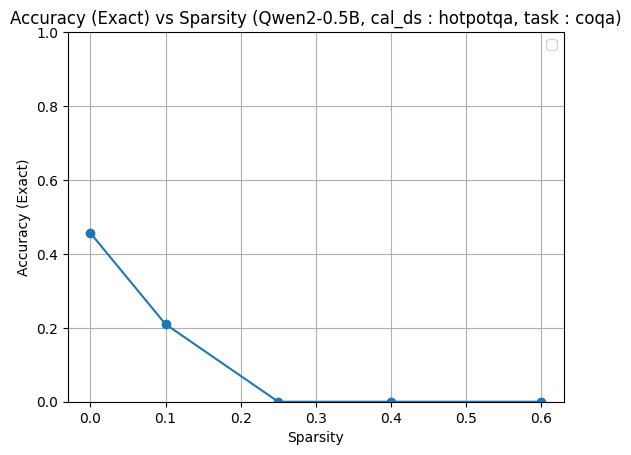

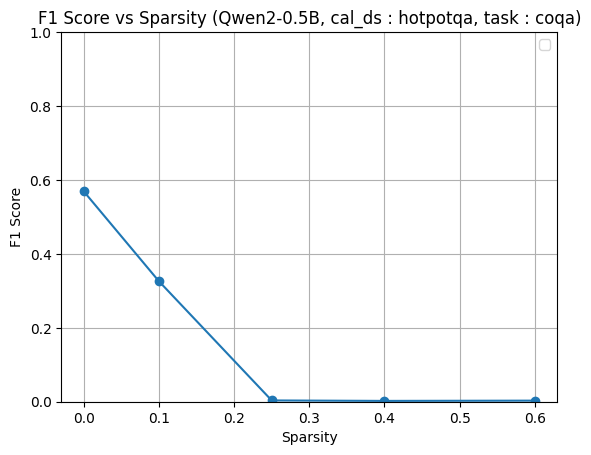

In [ ]:
#important the dataset defines which calibration dataset was used
import json
result_hotpotqa_coqa = load_results("Qwen/Qwen2-0.5B", "hotpotqa", ["coqa"], "coqa")
plot_metric(result_hotpotqa_coqa, "em,none", "Accuracy (Exact)", "Qwen2-0.5B, cal_ds : hotpotqa, task : coqa")
plot_metric(result_hotpotqa_coqa, "f1,none", "F1 Score", "Qwen2-0.5B, cal_ds : hotpotqa, task : coqa")

/tmp/ipython-input-4268717479.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


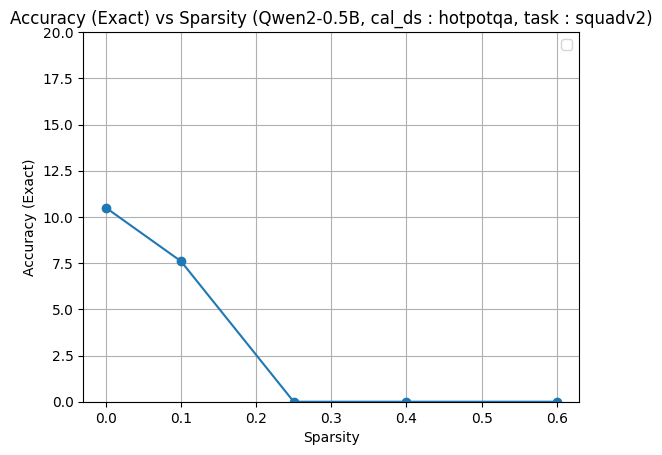

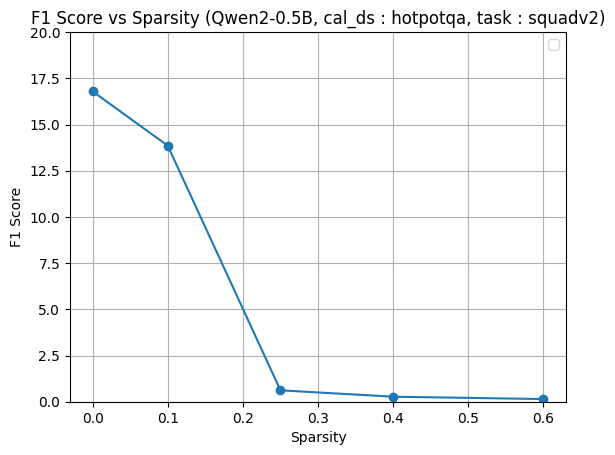

In [ ]:
result_hotpotqa_squadv2 = load_results("Qwen/Qwen2-0.5B", "hotpotqa", ["squadv2"], "squadv2")
plot_metric(result_hotpotqa_squadv2, "exact,none", "Accuracy (Exact)", "Qwen2-0.5B, cal_ds : hotpotqa, task : squadv2")
plot_metric(result_hotpotqa_squadv2, "f1,none", "F1 Score", "Qwen2-0.5B, cal_ds : hotpotqa, task : squadv2")

/tmp/ipython-input-4112955871.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


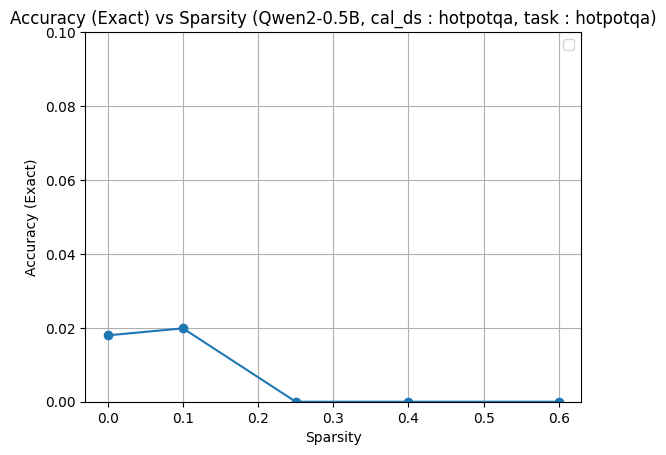

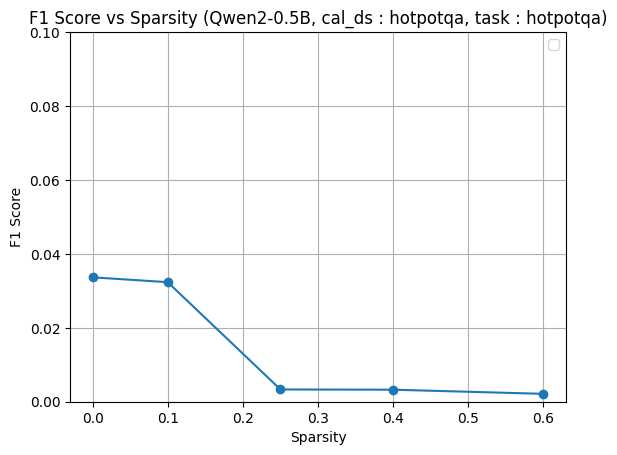

In [ ]:
result_hotpotqa_hotpotqa = load_results("Qwen/Qwen2-0.5B", "hotpotqa", ["hotpotqa"], "metrics")
plot_metric(result_hotpotqa_hotpotqa, "em", "Accuracy (Exact)", "Qwen2-0.5B, cal_ds : hotpotqa, task : hotpotqa")
plot_metric(result_hotpotqa_hotpotqa, "f1", "F1 Score", "Qwen2-0.5B, cal_ds : hotpotqa, task : hotpotqa")

/tmp/ipython-input-3537764825.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


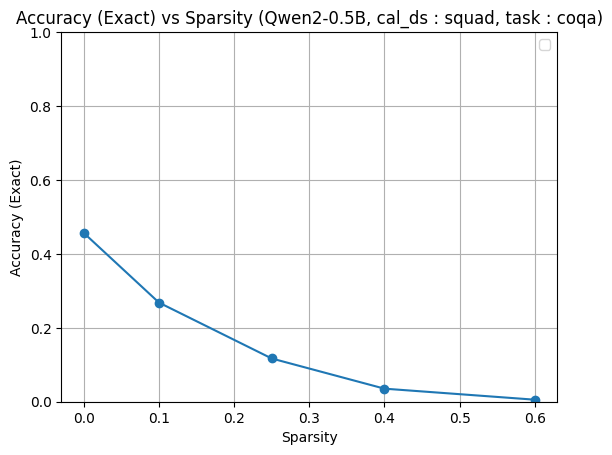

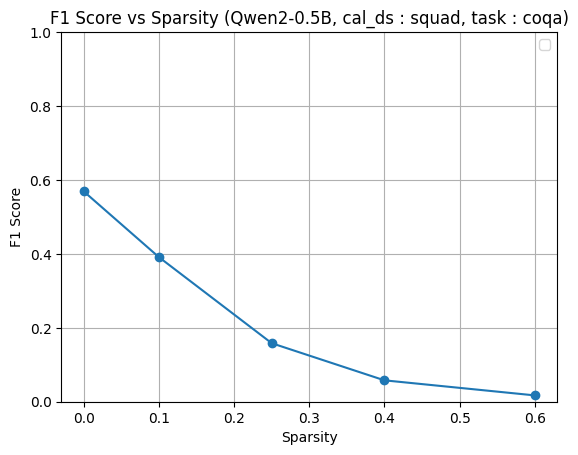

In [ ]:
result_squadv1_coqa = load_results("Qwen/Qwen2-0.5B", "squad", ["coqa"], "coqa")
plot_metric(result_squadv1_coqa, "em,none", "Accuracy (Exact)", "Qwen2-0.5B, cal_ds : squad, task : coqa")
plot_metric(result_squadv1_coqa, "f1,none", "F1 Score", "Qwen2-0.5B, cal_ds : squad, task : coqa")

/tmp/ipython-input-4268717479.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


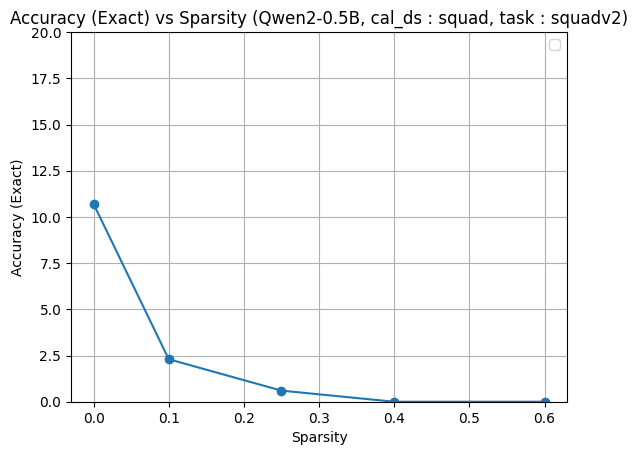

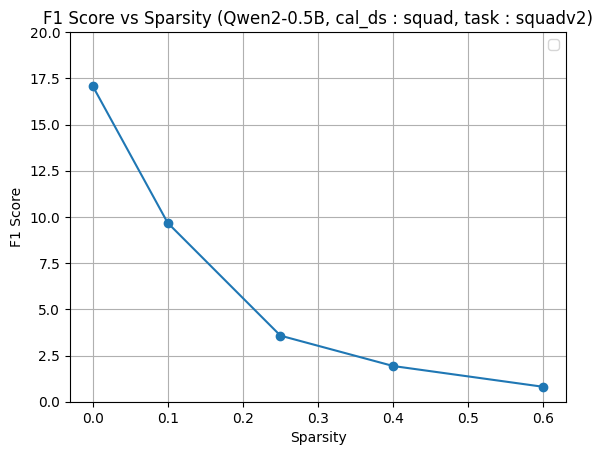

In [ ]:
result_squadv1_squadv2 = load_results("Qwen/Qwen2-0.5B", "squad", ["squadv2"], "squadv2")
plot_metric(result_squadv1_squadv2, "exact,none", "Accuracy (Exact)", "Qwen2-0.5B, cal_ds : squad, task : squadv2")
plot_metric(result_squadv1_squadv2, "f1,none", "F1 Score", "Qwen2-0.5B, cal_ds : squad, task : squadv2")

/tmp/ipython-input-4112955871.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


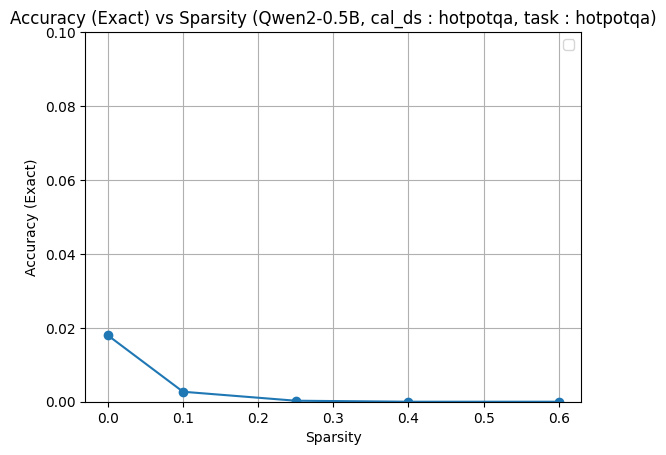

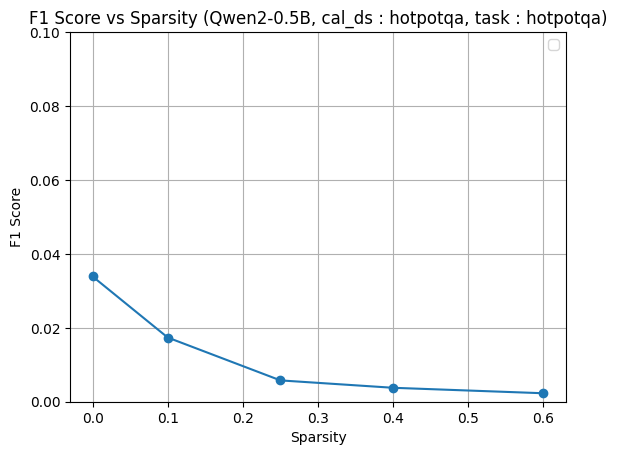

In [ ]:
result_squad_hotpotqa = load_results("Qwen/Qwen2-0.5B", "squad", ["hotpot"], "metrics")
plot_metric(result_squad_hotpotqa, "em", "Accuracy (Exact)", "Qwen2-0.5B, cal_ds : squad, task : hotpotqa")
plot_metric(result_squad_hotpotqa, "f1", "F1 Score", "Qwen2-0.5B, cal_ds : squad, task : hotpotqa")

/tmp/ipython-input-3537764825.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


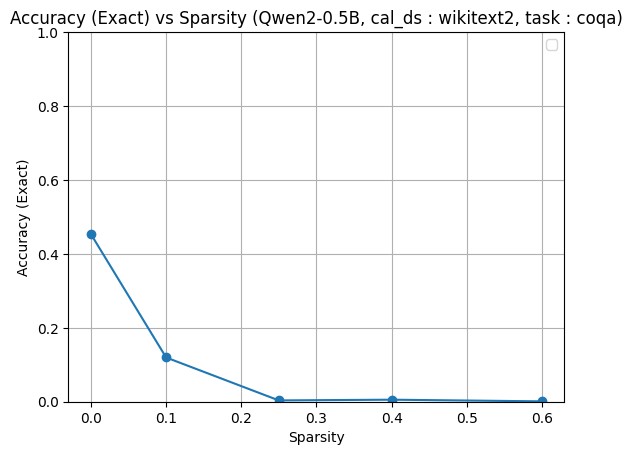

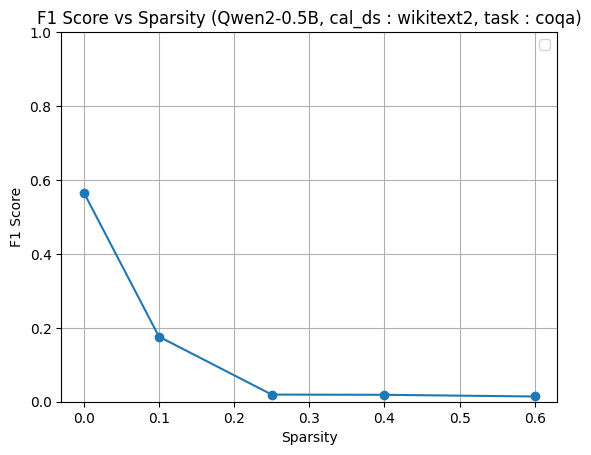

In [ ]:
result_wikitext2_coqa = load_results("Qwen/Qwen2-0.5B", "wikitext2", ["coqa"], "coqa")
plot_metric(result_wikitext2_coqa, "em,none", "Accuracy (Exact)", "Qwen2-0.5B, cal_ds : wikitext2, task : coqa")
plot_metric(result_wikitext2_coqa, "f1,none", "F1 Score", "Qwen2-0.5B, cal_ds : wikitext2, task : coqa")

/tmp/ipython-input-4268717479.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


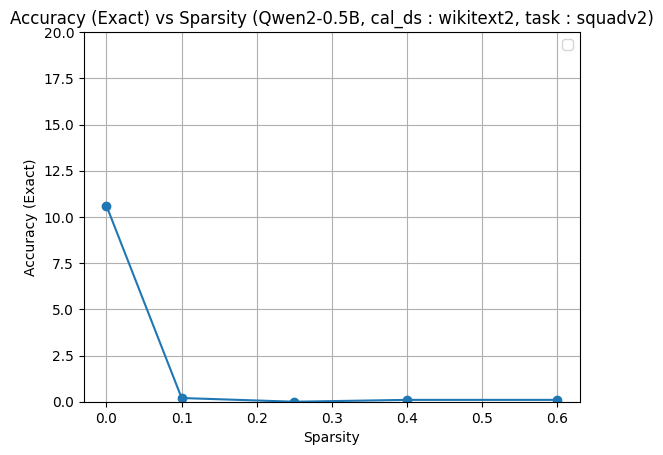

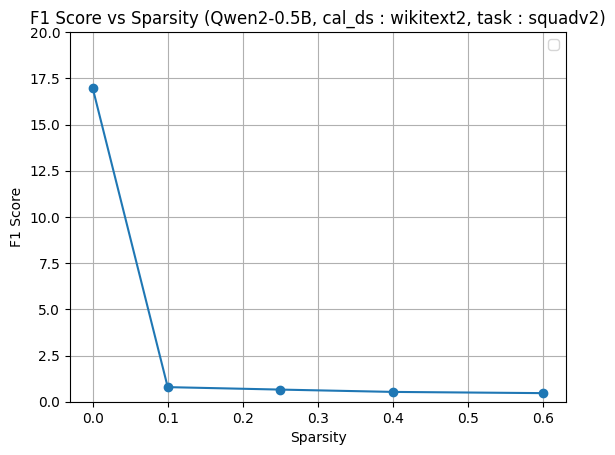

In [8]:
import json
result_wikitext2_squadv2 = load_results("Qwen/Qwen2-0.5B", "wikitext2", ["squadv2"], "squadv2")
plot_metric(result_wikitext2_squadv2, "exact,none", "Accuracy (Exact)", "Qwen2-0.5B, cal_ds : wikitext2, task : squadv2")
plot_metric(result_wikitext2_squadv2, "f1,none", "F1 Score", "Qwen2-0.5B, cal_ds : wikitext2, task : squadv2")

/tmp/ipython-input-4112955871.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


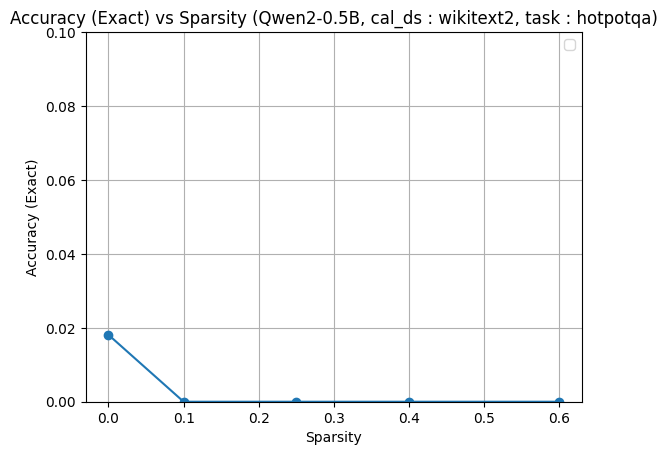

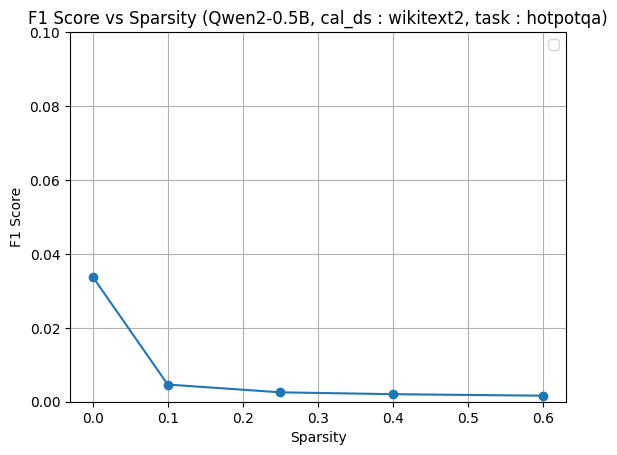

In [ ]:
result_wikitext2_hotpotqa = load_results("Qwen/Qwen2-0.5B", "wikitext2", ["hotpot"], "metrics")
plot_metric(result_wikitext2_hotpotqa, "em", "Accuracy (Exact)", "Qwen2-0.5B, cal_ds : wikitext2, task : hotpotqa")
plot_metric(result_wikitext2_hotpotqa, "f1", "F1 Score", "Qwen2-0.5B, cal_ds : wikitext2, task : hotpotqa")